# 10 · Renewal processes

Replace the Poisson process's exponential gaps by any positive i.i.d. lifetimes and you have a renewal process:
component replacements, bus arrivals, machine restarts. Memory returns - the age of the current component
matters - and with it the renewal function, the renewal-reward theorem that prices maintenance policies, and
the inspection paradox that makes the bus you wait for later than average.

**What you will learn**
- compute and interpret the renewal function
- explain and quantify the inspection paradox
- price maintenance policies with the renewal-reward theorem
- compute availability of alternating renewal systems

**Before you start:** notebook 09  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import renewal as rn
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## The renewal function

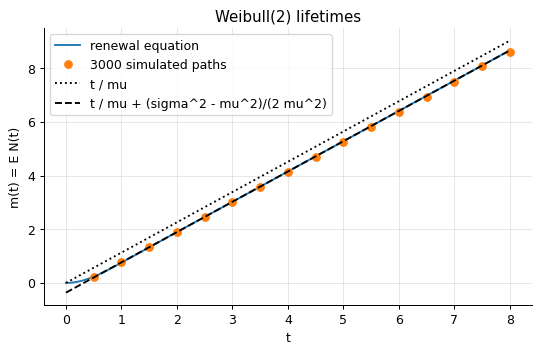

m(1.0) = 0.7537;  asymptote 0.7650
m(4.0) = 4.1501;  asymptote 4.1501
m(8.0) = 8.6637;  asymptote 8.6637


In [2]:
wm = rn.weibull_moments(2.0, 1.0)
cdf = lambda x: 1 - np.exp(-(x**2))
t, m = rn.renewal_function(cdf, 8.0, 3000)
sim_t = np.arange(0.5, 8.01, 0.5)
sims = np.array([[np.searchsorted(rn.simulate(lambda n, r: r.weibull(2.0, n), 9.0, R(1000 * k + i)), tt, side="right") for tt in sim_t] for k, i in zip(range(3000), range(3000))])
plt.plot(t, m, label="renewal equation"); plt.plot(sim_t, sims.mean(axis=0), "o", label="3000 simulated paths")
plt.plot(t, t / wm["mean"], "k:", label="t / mu"); plt.plot(t, rn.asymptote(t, wm["mean"], wm["var"]), "k--", label="t / mu + (sigma^2 - mu^2)/(2 mu^2)")
plt.legend(); plt.xlabel("t"); plt.ylabel("m(t) = E N(t)"); plt.title("Weibull(2) lifetimes"); plt.show()
for x in (1.0, 4.0, 8.0):
    print(f"m({x}) = {np.interp(x, t, m):.4f};  asymptote {rn.asymptote(x, wm['mean'], wm['var']):.4f}")

The renewal function solves m(t) = F(t) + ∫₀ᵗ m(t − s) dF(s) (condition on the first renewal); a trapezoidal
discretisation solves it to five digits. The elementary renewal theorem gives m(t)/t → 1/μ, and Smith's key
renewal theorem adds the constant (σ² − μ²)/(2μ²): lifetimes less variable than the exponential (Weibull with
shape 2 has cv 0.52) give fewer renewals than t/μ early on.

## The inspection paradox

In [3]:
rows = []
for name, sampler, mean, m2 in (("exponential, mean 1", lambda n, r: r.exponential(1.0, n), 1.0, 2.0), ("Weibull(2, 1)", lambda n, r: r.weibull(2.0, n), wm["mean"], wm["second_moment"]),
                               ("uniform(0.5, 1.5)", lambda n, r: r.uniform(0.5, 1.5, n), 1.0, 1 + 1 / 12), ("lognormal, cv 2", lambda n, r: r.lognormal(-0.5 * np.log(5), np.sqrt(np.log(5)), n), 1.0, 5.0)):
    ins = rn.inspect(sampler, 40.0, 4000, R(len(name)))
    rows.append((name, mean, ins["length"].mean(), rn.length_biased_mean(mean, m2), ins["residual"].mean(), rn.mean_residual_life(mean, m2)))
print(pd.DataFrame(rows, columns=["inter-renewal law", "E[X]", "mean interval seen", "E[X^2]/E[X]", "mean wait", "E[X^2]/(2E[X])"]).to_string(index=False, float_format="%.3f"))

  inter-renewal law  E[X]  mean interval seen  E[X^2]/E[X]  mean wait  E[X^2]/(2E[X])
exponential, mean 1 1.000               1.979        2.000      0.992           1.000
      Weibull(2, 1) 0.886               1.131        1.128      0.563           0.564
  uniform(0.5, 1.5) 1.000               1.080        1.083      0.536           0.542
    lognormal, cv 2 1.000               4.721        5.000      2.387           2.500


An observer arriving at a fixed time lands in a long interval more often than a short one - length-biased
sampling - and sees a mean interval E[X²]/E[X] ≥ E[X]. With exponential gaps the interval seen is twice the
average and the wait for the next renewal is a full mean gap (memorylessness); with nearly regular gaps the
wait approaches half a gap; with highly variable gaps it is worse than a full mean gap (the lognormal estimate
is noisy - its length-biased law has a heavy tail). Passengers at a bus stop, class sizes
reported by students, and hospital-stay surveys all suffer this bias.

## Renewal-reward: when should a part be replaced?

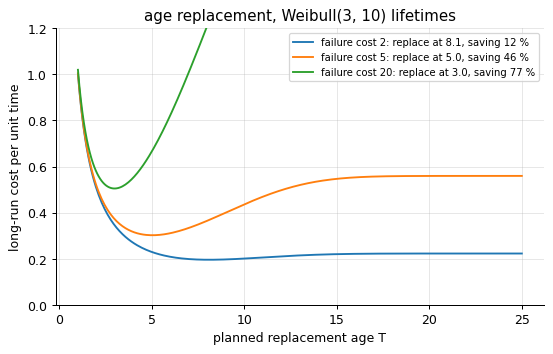

exponential lifetimes: cost always decreasing in T -> True


In [4]:
shape, scale = 3.0, 10.0
surv = lambda x: np.exp(-((np.asarray(x) / scale) ** shape))
T = np.linspace(1, 25, 300)
for cf in (2.0, 5.0, 20.0):
    o = rn.optimal_age_replacement(surv, 1.0, cf, T)
    run_to_failure = cf / rn.weibull_moments(shape, scale)["mean"]
    plt.plot(T, o["costs"], label=f"failure cost {cf:g}: replace at {o['T']:.1f}, saving {100 * (1 - o['cost_rate'] / run_to_failure):.0f} %")
plt.ylim(0, 1.2); plt.xlabel("planned replacement age T"); plt.ylabel("long-run cost per unit time"); plt.legend(fontsize=8); plt.title("age replacement, Weibull(3, 10) lifetimes"); plt.show()
print("exponential lifetimes: cost always decreasing in T ->", bool(np.all(np.diff(rn.age_replacement_cost(T, lambda x: np.exp(-np.asarray(x) / 10), 1.0, 5.0)) < 0)))

Each replacement starts a new cycle, so the long-run cost rate is E[cycle cost]/E[cycle length] (the
renewal-reward theorem) - here (c_p R(T) + c_f (1 − R(T))) / ∫₀ᵀ R(t) dt. With wear-out (increasing hazard)
and expensive failures, preventive replacement saves up to two-thirds of the cost; with exponential lifetimes
it never pays, because an old part is as good as new.

## Availability: the alternating renewal process

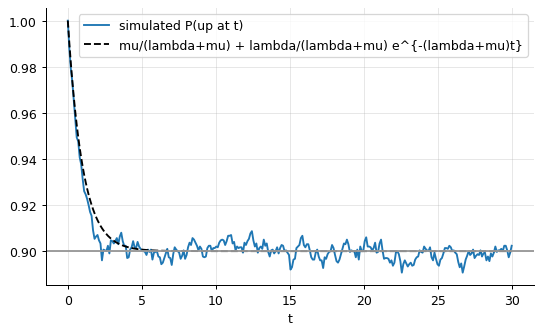

long-run availability E[U]/(E[U] + E[D]) = 0.9000 - the same for any up and down distributions with these means


In [5]:
t = np.linspace(0, 30, 300)
lam, mu = 0.1, 0.9
up_down = []
for k in range(3000):
    r = R(5000 + k); s, up, times, states = 0.0, True, [0.0], [1]
    while s < 30:
        s += r.exponential(1 / lam) if up else r.exponential(1 / mu)
        up = not up; times.append(s); states.append(int(up))
    up_down.append(np.array(states)[np.searchsorted(times, t, side="right") - 1])
plt.plot(t, np.mean(up_down, axis=0), label="simulated P(up at t)"); plt.plot(t, rn.availability_exponential(t, lam, mu), "k--", label="mu/(lambda+mu) + lambda/(lambda+mu) e^{-(lambda+mu)t}")
plt.axhline(rn.availability(1 / lam, 1 / mu), color="0.6"); plt.legend(); plt.xlabel("t"); plt.show()
print(f"long-run availability E[U]/(E[U] + E[D]) = {rn.availability(10.0, 1 / 0.9):.4f} - the same for any up and down distributions with these means")

A unit alternating between up and down periods is available a fraction E[U]/(E[U] + E[D]) of the time in the
long run, whatever the distributions - an *insensitivity* that makes the formula robust. The transient
approach depends on the distributions; for exponential periods it is a single exponential at rate λ + μ.

## Inside the algorithm: one step of the renewal-equation scheme

In [6]:
F = lambda x: 1 - np.exp(-2 * x)
hh = 0.01; k = 3; tk = np.arange(k + 1) * hh; Fk = F(tk); dF = np.diff(Fk)
m_prev = 2.0 * tk[:k]                                    # exact m on the earlier grid points
rest = Fk[k] + 0.5 * np.dot(dF[:k], np.r_[0.0, m_prev[:0:-1]] + m_prev[::-1])
print(f"m(t_3) by the scheme {rest / (1 - 0.5 * dF[0]):.8f}, exact {2 * tk[k]:.8f}")

m(t_3) by the scheme 0.05999804, exact 0.06000000


## Exercises
1. Buses arrive as a renewal process with gamma inter-arrival times of mean 10 min. For shape 0.5, 1, 4 and infinity (deterministic), compute and simulate a passenger's mean wait. What does a schedule with cv 1.5 cost passengers?
2. A component has a lognormal lifetime (median 2000 h, sigma 0.6). Planned replacement costs 1, failure 8. Find the optimal replacement age and the saving over run-to-failure.
3. **Implement it yourself:** write the renewal-equation solver from scratch for a given cdf on a uniform grid and check it against the Erlang-2 closed form.